In [ ]:
# Run this cell to set the working directory to the repo root.
from pathlib import Path
import os, sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "method.py").exists() and (p / "tools").is_dir())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


# Screeplots for manuscript real-data experiments

This notebook loads saved DE runs and produces screeplots for the real-data/loss combinations used in `main.tex` and `Real_loss_comparison.ipynb`:

- Healthy with `Loss1`
- T1D with `Loss1`
- Combined with `Loss2`
- AI-READI with `Loss2`

The helper functions below also work for the other real-data/loss combinations; the sections here focus only on the manuscript's settled choices.

**Workflow:** from the repo root,
1. For one `(dataset, loss, K)` job, run for example:
   ```powershell

   python tools/screeplot_real.py --dataset healthy --K 3

   ```
2. For the three manuscript datasets that still need local runs, use the built-in paired batch mode:
   ```powershell

   python tools/screeplot_real.py --datasets healthy t1d combined --max-workers 5

   ```
   This runs `K=1,\ldots,10` in five paired workers: `(1,10)`, `(2,9)`, `(3,8)`, `(4,7)`, `(5,6)`.
3. Each run saves a pickle file to `results/screeplot/{dataset}_{loss}_K{K}.pkl`. 
4. Once the runs finish, execute this notebook to print thresholds and losses, then generate and save one screeplot PDF per manuscript configuration.


In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from tools.real_loss_tools import DATASET_SPECS

np.set_printoptions(precision=4, suppress=True)

REPO_ROOT = Path.cwd()
RESULTS_DIR = REPO_ROOT / 'results' / 'screeplot'
K_VALUES = list(range(1, 11))
DATASET_LABELS = dict(DATASET_SPECS)
LOSS_LABELS = {'Loss1': r'$L_1$', 'Loss2': r'$L_2$'}


## Helpers

These helpers load saved results for any real-data cohort and either `Loss1` or `Loss2`.


In [11]:
def _result_path(dataset_key, loss, threshold_count):
    return RESULTS_DIR / f'{dataset_key}_{loss}_K{threshold_count}.pkl'


def _plot_path(dataset_key, loss):
    return RESULTS_DIR / f'screeplot_{dataset_key}_{loss}.pdf'


def _format_thresholds(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return '{}'
    formatted = [f'{value:.2f}'.rstrip('0').rstrip('.') for value in values]
    return '{' + ', '.join(formatted) + '}'


def load_screeplot_summary(dataset_key, loss, K_values=K_VALUES):
    rows = []
    missing_paths = []

    for threshold_count in K_values:
        fpath = _result_path(dataset_key, loss, threshold_count)
        if not fpath.exists():
            missing_paths.append(str(fpath))
            continue

        with fpath.open('rb') as file_obj:
            result = pickle.load(file_obj)

        cutoffs = np.asarray(result['best_cutoffs'], dtype=float)[1:-1]
        print(
            f"K={threshold_count:2d}  |  {loss} = {result['min_loss']:.6f}  |  "
            f"cutoffs = {np.round(cutoffs, 2)}"
        )
        rows.append(
            {
                'K': threshold_count,
                'Loss value': float(result['min_loss']),
                'Thresholds': _format_thresholds(cutoffs),
            }
        )

    if missing_paths:
        missing_text = '\n'.join(missing_paths)
        raise FileNotFoundError(f'Missing screeplot result files:\n{missing_text}')

    return pd.DataFrame(rows)


def render_screeplot(dataset_key, dataset_label, loss, summary_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(summary_df['K'], summary_df['Loss value'], 'o-', color='#2c7bb6', markersize=7, linewidth=2, zorder=3)

    ax.set_xlabel('Number of thresholds ($K$)', fontsize=13)
    ax.set_ylabel(f'Optimal {LOSS_LABELS[loss]} loss', fontsize=13)
    ax.set_title(f'{dataset_label} ({LOSS_LABELS[loss]} loss)', fontsize=14)

    ax.set_xticks(summary_df['K'])
    ax.xaxis.set_major_locator(ticker.FixedLocator(summary_df['K']))
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(summary_df['K'].min() - 0.5, summary_df['K'].max() + 0.5)

    out_path = _plot_path(dataset_key, loss)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches='tight', format='pdf', dpi=500)
    plt.show()
    print(f'Saved plot to {out_path}')
    return out_path


def run_screeplot_section(dataset_key, loss):
    dataset_label = DATASET_LABELS[dataset_key]
    summary_df = load_screeplot_summary(dataset_key, loss)
    render_screeplot(dataset_key, dataset_label, loss, summary_df)
    return summary_df


## Healthy dataset ($L_1$)


K= 1  |  Loss1 = 180.106189  |  cutoffs = [133.56]
K= 2  |  Loss1 = 88.907736  |  cutoffs = [ 71.69 127.91]
K= 3  |  Loss1 = 30.361369  |  cutoffs = [ 76.87 113.31 146.26]
K= 4  |  Loss1 = 16.619439  |  cutoffs = [ 75.83 100.69 123.7  154.96]
K= 5  |  Loss1 = 8.612661  |  cutoffs = [ 69.01  84.95 106.06 127.06 157.89]
K= 6  |  Loss1 = 4.368155  |  cutoffs = [ 67.47  82.36 100.76 117.34 138.09 167.82]
K= 7  |  Loss1 = 2.727072  |  cutoffs = [ 67.43  80.07  94.94 108.42 123.33 142.56 170.67]
K= 8  |  Loss1 = 1.726936  |  cutoffs = [ 65.37  77.49  88.1  101.78 115.37 130.65 149.12 178.27]
K= 9  |  Loss1 = 1.196815  |  cutoffs = [ 63.26  74.53  84.29  96.92 108.17 120.28 135.45 152.95 180.69]
K=10  |  Loss1 = 0.830227  |  cutoffs = [ 62.89  73.45  82.92  92.32 102.14 113.16 125.14 139.05 157.72 183.06]


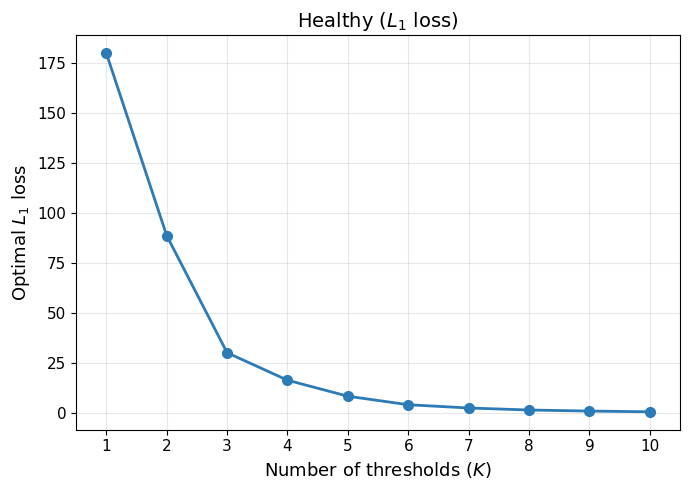

Saved plot to g:\My Drive\Experiments\OptiThresholds\results\screeplot\screeplot_healthy_Loss1.pdf


In [12]:
healthy_loss1_df = run_screeplot_section('healthy', 'Loss1')


## T1D dataset ($L_1$)


K= 1  |  Loss1 = 602.931069  |  cutoffs = [244.51]
K= 2  |  Loss1 = 398.213164  |  cutoffs = [210.48 288.43]
K= 3  |  Loss1 = 96.184618  |  cutoffs = [ 83.06 191.21 278.86]
K= 4  |  Loss1 = 41.215727  |  cutoffs = [ 84.88 171.2  232.62 301.58]
K= 5  |  Loss1 = 25.869426  |  cutoffs = [ 84.36 154.29 203.19 255.81 314.5 ]
K= 6  |  Loss1 = 13.445713  |  cutoffs = [ 69.28  98.48 156.32 204.08 256.9  314.5 ]
K= 7  |  Loss1 = 7.960858  |  cutoffs = [ 68.39  97.58 146.2  187.45 229.18 273.63 323.5 ]
K= 8  |  Loss1 = 5.589626  |  cutoffs = [ 68.57  96.21 137.32 172.11 208.57 245.09 285.2  330.4 ]
K= 9  |  Loss1 = 4.045566  |  cutoffs = [ 64.85  86.56 108.73 145.15 179.43 213.19 248.74 286.06 330.38]
K=10  |  Loss1 = 3.079253  |  cutoffs = [ 63.42  84.49 106.25 143.09 176.32 210.45 246.15 285.35 330.67 383.87]


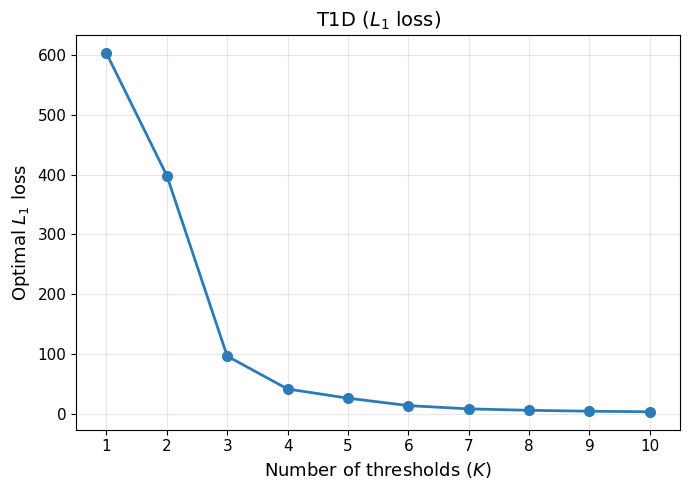

Saved plot to g:\My Drive\Experiments\OptiThresholds\results\screeplot\screeplot_t1d_Loss1.pdf


In [13]:
t1d_loss1_df = run_screeplot_section('t1d', 'Loss1')


## Combined dataset ($L_2$)


K= 1  |  Loss2 = 84.400097  |  cutoffs = [195.02]
K= 2  |  Loss2 = 22.163946  |  cutoffs = [149.7  257.25]
K= 3  |  Loss2 = 13.121986  |  cutoffs = [134.92 212.8  286.56]
K= 4  |  Loss2 = 4.911651  |  cutoffs = [ 81.49 125.04 192.4  274.25]
K= 5  |  Loss2 = 2.290306  |  cutoffs = [ 76.08 109.78 155.02 216.1  286.46]
K= 6  |  Loss2 = 1.268773  |  cutoffs = [ 76.59 109.45 153.41 210.94 275.83 374.85]
K= 7  |  Loss2 = 0.748166  |  cutoffs = [ 70.93  89.2  119.6  163.78 222.74 287.04 386.28]
K= 8  |  Loss2 = 0.402498  |  cutoffs = [ 71.45  90.29 116.15 150.28 197.55 248.59 309.85 397.57]
K= 9  |  Loss2 = 0.245359  |  cutoffs = [ 66.79  83.33 105.71 133.   164.29 210.03 257.26 313.83 396.2 ]
K=10  |  Loss2 = 0.142674  |  cutoffs = [ 65.68  79.93  96.72 118.77 146.85 183.05 224.74 270.85 324.59 400.54]


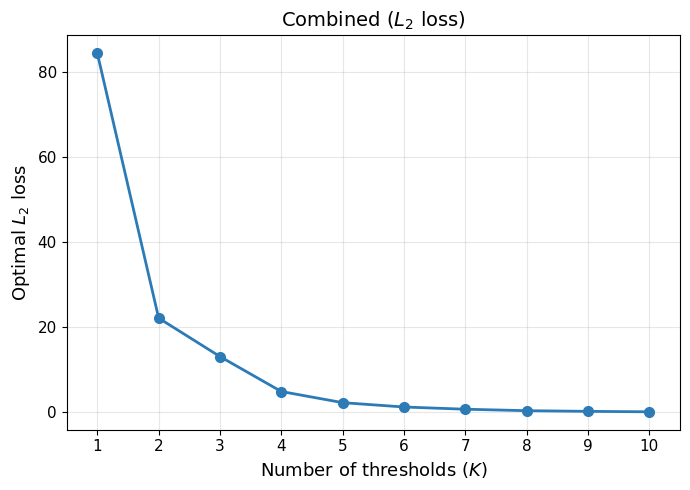

Saved plot to g:\My Drive\Experiments\OptiThresholds\results\screeplot\screeplot_combined_Loss2.pdf


In [14]:
combined_loss2_df = run_screeplot_section('combined', 'Loss2')


## AI-READI dataset ($L_2$)


K= 1  |  Loss2 = 81.860282  |  cutoffs = [173.32]
K= 2  |  Loss2 = 45.483381  |  cutoffs = [ 95.75 169.48]
K= 3  |  Loss2 = 12.307016  |  cutoffs = [ 92.53 142.16 206.12]
K= 4  |  Loss2 = 5.513501  |  cutoffs = [ 89.16 127.79 171.95 231.35]
K= 5  |  Loss2 = 2.604669  |  cutoffs = [ 78.64 104.34 138.76 181.84 245.71]
K= 6  |  Loss2 = 1.288086  |  cutoffs = [ 76.57  99.57 126.2  158.69 196.46 256.51]
K= 7  |  Loss2 = 0.860014  |  cutoffs = [ 73.86  95.01 118.14 144.79 176.87 217.34 275.79]
K= 8  |  Loss2 = 0.551979  |  cutoffs = [ 50.89  78.73  98.79 120.51 145.92 176.59 213.75 268.03]
K= 9  |  Loss2 = 0.362681  |  cutoffs = [ 44.33  75.04  96.83 117.64 140.39 165.45 195.37 234.48 287.41]
K=10  |  Loss2 = 0.242539  |  cutoffs = [ 44.52  73.27  91.92 108.65 127.8  149.86 173.31 201.64 241.77 289.46]


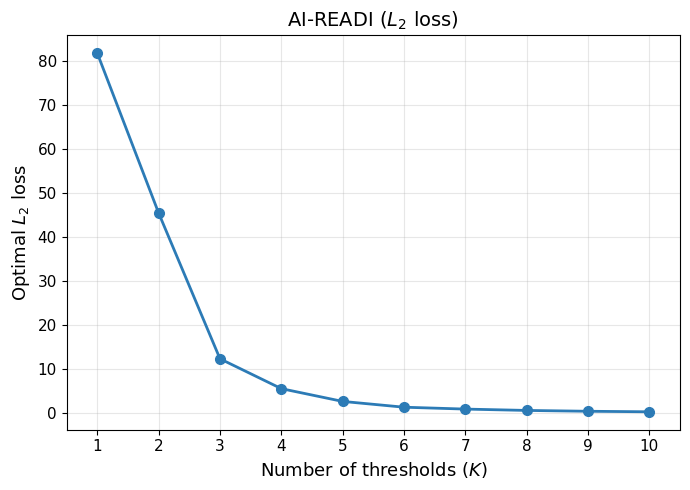

Saved plot to g:\My Drive\Experiments\OptiThresholds\results\screeplot\screeplot_aireadi_Loss2.pdf


In [15]:
ai_readi_loss2_df = run_screeplot_section('aireadi', 'Loss2')
